<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_04/avcad_exer04_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 4**

Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

### Exercise Questions

In this exercise you will use the dataset in `EFIplus_medit.zip` to:
1. Using an appropriate visualization, explore how Mean Annual Temperature (Temp_ann) may affect the
presence of Salmo trutta fario (Brown Trout).
2. Check the same effect but now separately for Minho and Tagus catchments and comparing the “effect
sizes”.
3. Test, using both visualization and hypothesis testing methods, if the actual_river_slope is drawn from a
normal distribution.
4. Take 100 samples of 2000 observations of actual_river_slope with replacement, compute the mean for
each sample and plot the resulting histogram of means. Test if these 100 mean values are drawn from a
normal distribution.

In [1]:
# @title **1. Import Python Packages**

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [6]:
# @title **2. Data Preparation**

# Load data from Github (from exercise 3 folder)
url = 'https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip'
df = pd.read_csv(url, compression='zip', sep=';')

print(df)

       Site_code   Latitude  Longitude   Country Catchment_name  Galiza  \
0     ES_01_0002  38.102003  -4.096070     Spain   Guadalquivir       0   
1     ES_02_0001  40.530188  -1.887796     Spain           Tejo       0   
2     ES_02_0002  40.595432  -1.928079     Spain           Tejo       0   
3     ES_02_0003  40.656184  -1.989831     Spain           Tejo       0   
4     ES_02_0004  40.676402  -2.036274     Spain           Tejo       0   
...          ...        ...        ...       ...            ...     ...   
5006      PTVO60  40.641612  -8.325149  Portugal          Vouga       0   
5007      PTVO61  40.729015  -8.098851  Portugal          Vouga       0   
5008      PTVO62  40.727959  -8.107344  Portugal          Vouga       0   
5009      PTVO63  40.817783  -8.224903  Portugal          Vouga       0   
5010      PTVO64  40.794352  -8.255380  Portugal          Vouga       0   

      Subsample  Calib_EFI_Medit  Calib_connect  Calib_hydrol  ...  \
0             1              

In [3]:
# Clean the Data Set
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))

# Drop rows with NaN
df2 = df.dropna()
print(f"Shape after dropna: {df2.shape}")

Shape after dropna: (2822, 154)


In [27]:
# @title **3. Set Global Plot Settings**

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

### **4. Q1: Using an appropriate visualization, explore how Mean Annual Temperature (Temp_ann) may affect the presence of Salmo trutta fario (Brown Trout).**

To do this, we first need to identify whether brown trout is present or absent in the site. To do this, we will create a column indicating whether the said fish is present or absent in the site.

In [17]:
# Create presence/absence column for Salmo trutta fario
df2 = df2.copy()
df2['trout_present'] = df2['Salmo trutta fario'].apply(lambda x: 'Present' if x > 0 else 'Absent') # Create a new column. Present if trout is present, absent if not.

# Display output
print(f"\nBrown Trout presence counts:")
print(df2['trout_present'].value_counts())



Brown Trout presence counts:
trout_present
Present    2042
Absent      780
Name: count, dtype: int64


Now that we have this column, we can now do analysis on the effect of mean annual temperature in the presence of Salmo trutta fario or Brown Trout.

In [19]:
# @title Summary statistics
print("temp_ann by Brown Trout presence:\n")
# Show the summary statistics of grouped sites where trout is present or absent.
print(df2.groupby('trout_present')['temp_ann'].describe().round(2))

temp_ann by Brown Trout presence:

                count   mean   std   min   25%   50%   75%   max
trout_present                                                   
Absent          780.0  15.21  1.55  10.4  14.1  15.4  16.7  17.5
Present        2042.0  12.75  1.56   6.7  11.9  13.0  13.9  17.2


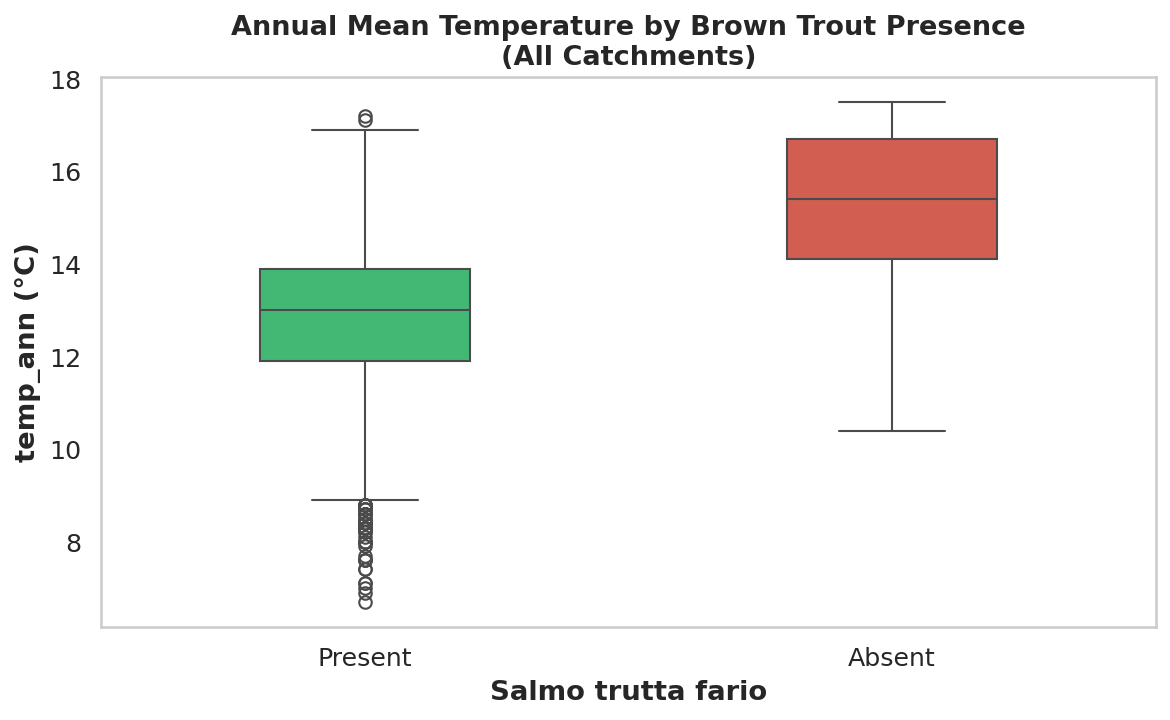

In [39]:
# @title Boxplot of Mean Temperature by Brown Trout Presence
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='trout_present', y='temp_ann', data=df2, ax=ax,
            hue='trout_present', palette={'Present': '#2ecc71', 'Absent': '#e74c3c'},
            order=['Present', 'Absent'], width=0.4, legend=False)
ax.set_title("Annual Mean Temperature by Brown Trout Presence\n(All Catchments)", fontsize=13)
ax.set_xlabel("Salmo trutta fario")
ax.set_ylabel("temp_ann (°C)")
ax.grid(False)
plt.tight_layout()
plt.show()

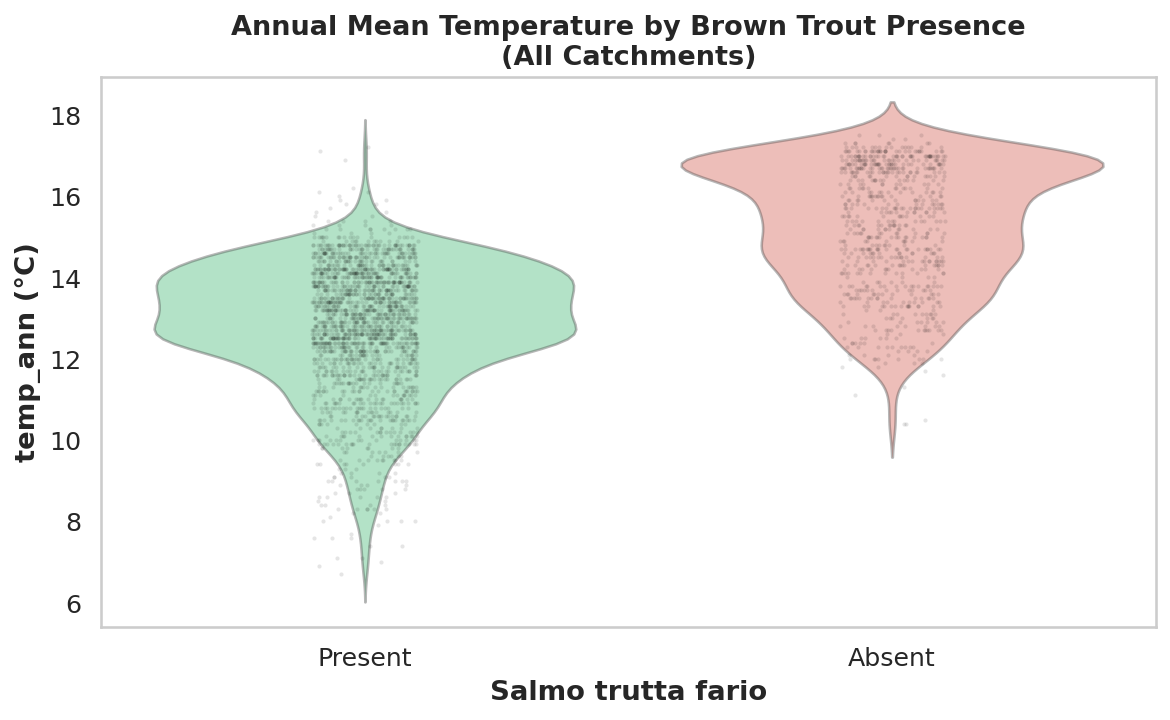

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(x='trout_present', y='temp_ann', data=df2, ax=ax,
               hue='trout_present', palette={'Present': '#2ecc71', 'Absent': '#e74c3c'},
               order=['Present', 'Absent'], inner=None, alpha=0.4, legend=False)
sns.stripplot(x='trout_present', y='temp_ann', data=df2, ax=ax,
              order=['Absent', 'Present'], color='black', alpha=0.1, size=2, jitter=True)
ax.set_title("Annual Mean Temperature by Brown Trout Presence\n(All Catchments)", fontsize=13)
ax.set_xlabel("Salmo trutta fario")
ax.set_ylabel("temp_ann (°C)")
ax.grid(False)
plt.tight_layout()
plt.show()

The boxplot shows Brown Trout is found where annual temperatures are lower (median ≈ 13.0 °C) compared to where it's absent (median ≈ 15.4 °C), with little overlap. The violin plot and data points highlight that the "Present" group clusters around 12–14 °C, while the "Absent" group clusters around 15–17 °C. This suggests Brown Trout prefers cooler waters, with a cutoff near 14–15 °C.

### **5. Q2: Same analysis for Minho and Tagus Catchments**

In [42]:
df_minho = df2[df2['Catchment_name'] == 'Minho'].copy()
df_tejo = df2[df2['Catchment_name'] == 'Tejo'].copy()

print("Minho catchment:")
print(f"  Total sites: {len(df_minho)}")
print(f"  Trout present: {(df_minho['trout_present'] == 'Present').sum()}")
print(f"  Trout absent:  {(df_minho['trout_present'] == 'Absent').sum()}")
print()
print("Tejo (Tagus) catchment:")
print(f"  Total sites: {len(df_tejo)}")
print(f"  Trout present: {(df_tejo['trout_present'] == 'Present').sum()}")
print(f"  Trout absent:  {(df_tejo['trout_present'] == 'Absent').sum()}")

Minho catchment:
  Total sites: 699
  Trout present: 688
  Trout absent:  11

Tejo (Tagus) catchment:
  Total sites: 235
  Trout present: 46
  Trout absent:  189


/tmp/ipykernel_362/1179870705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='trout_present', y='temp_ann', data=data, ax=ax,
/tmp/ipykernel_362/1179870705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='trout_present', y='temp_ann', data=data, ax=ax,


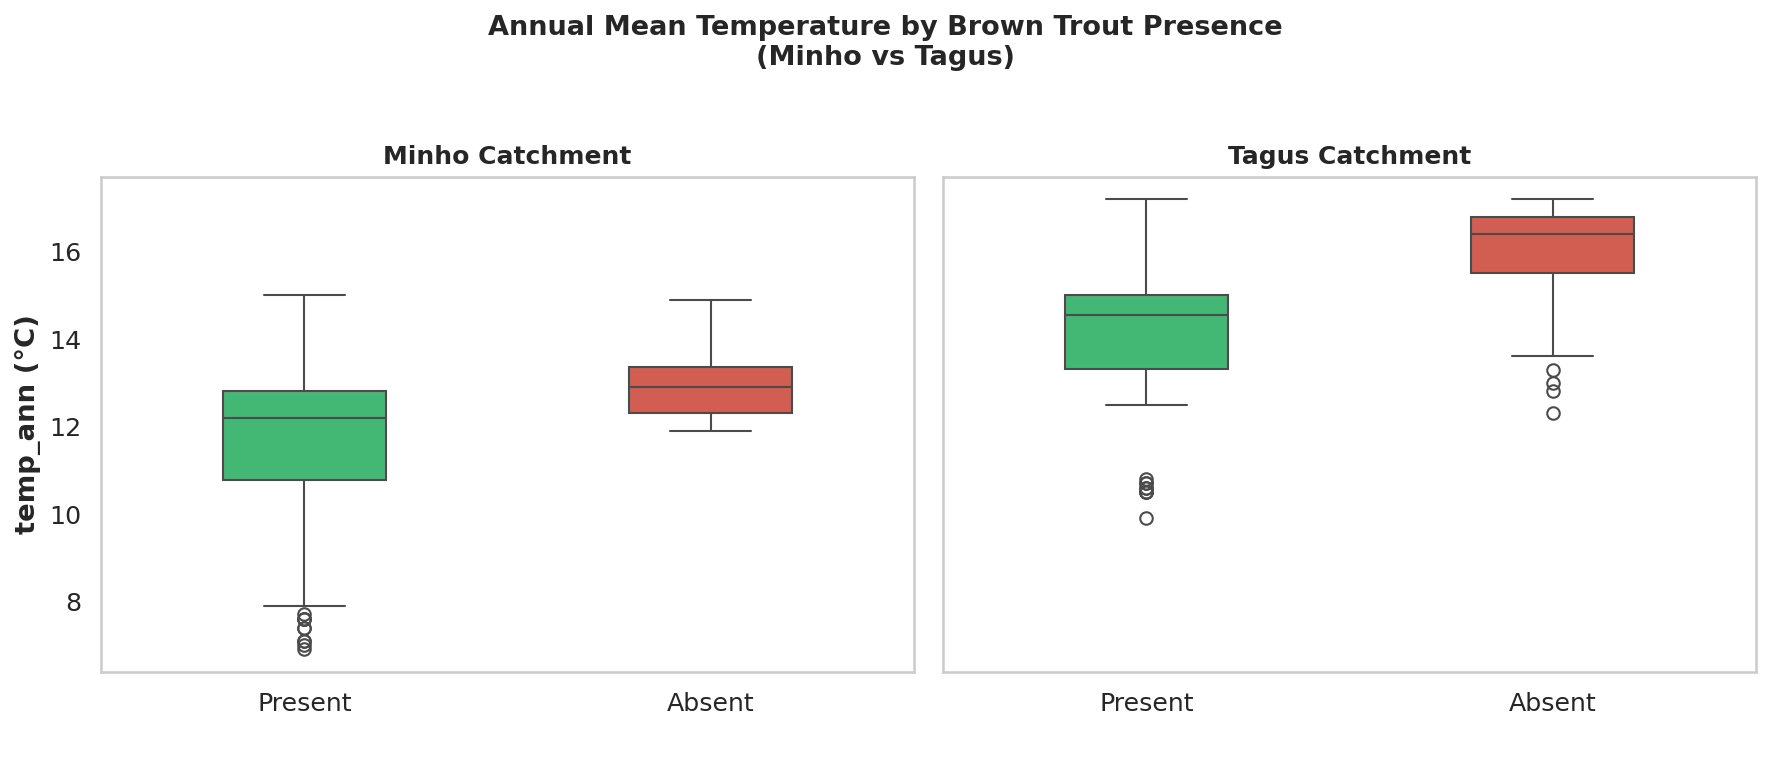

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (name, data) in zip(axes, [('Minho', df_minho), ('Tagus', df_tejo)]):
    sns.boxplot(x='trout_present', y='temp_ann', data=data, ax=ax,
                palette={'Present': '#2ecc71', 'Absent': '#e74c3c'},
                order=['Present', 'Absent'], width=0.4)
    ax.set_title(f"{name} Catchment", fontsize=12)
    ax.set_xlabel(" ")
    ax.set_ylabel("temp_ann (°C)" if ax == axes[0] else "")
    ax.grid(False)

fig.suptitle("Annual Mean Temperature by Brown Trout Presence\n(Minho vs Tagus)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

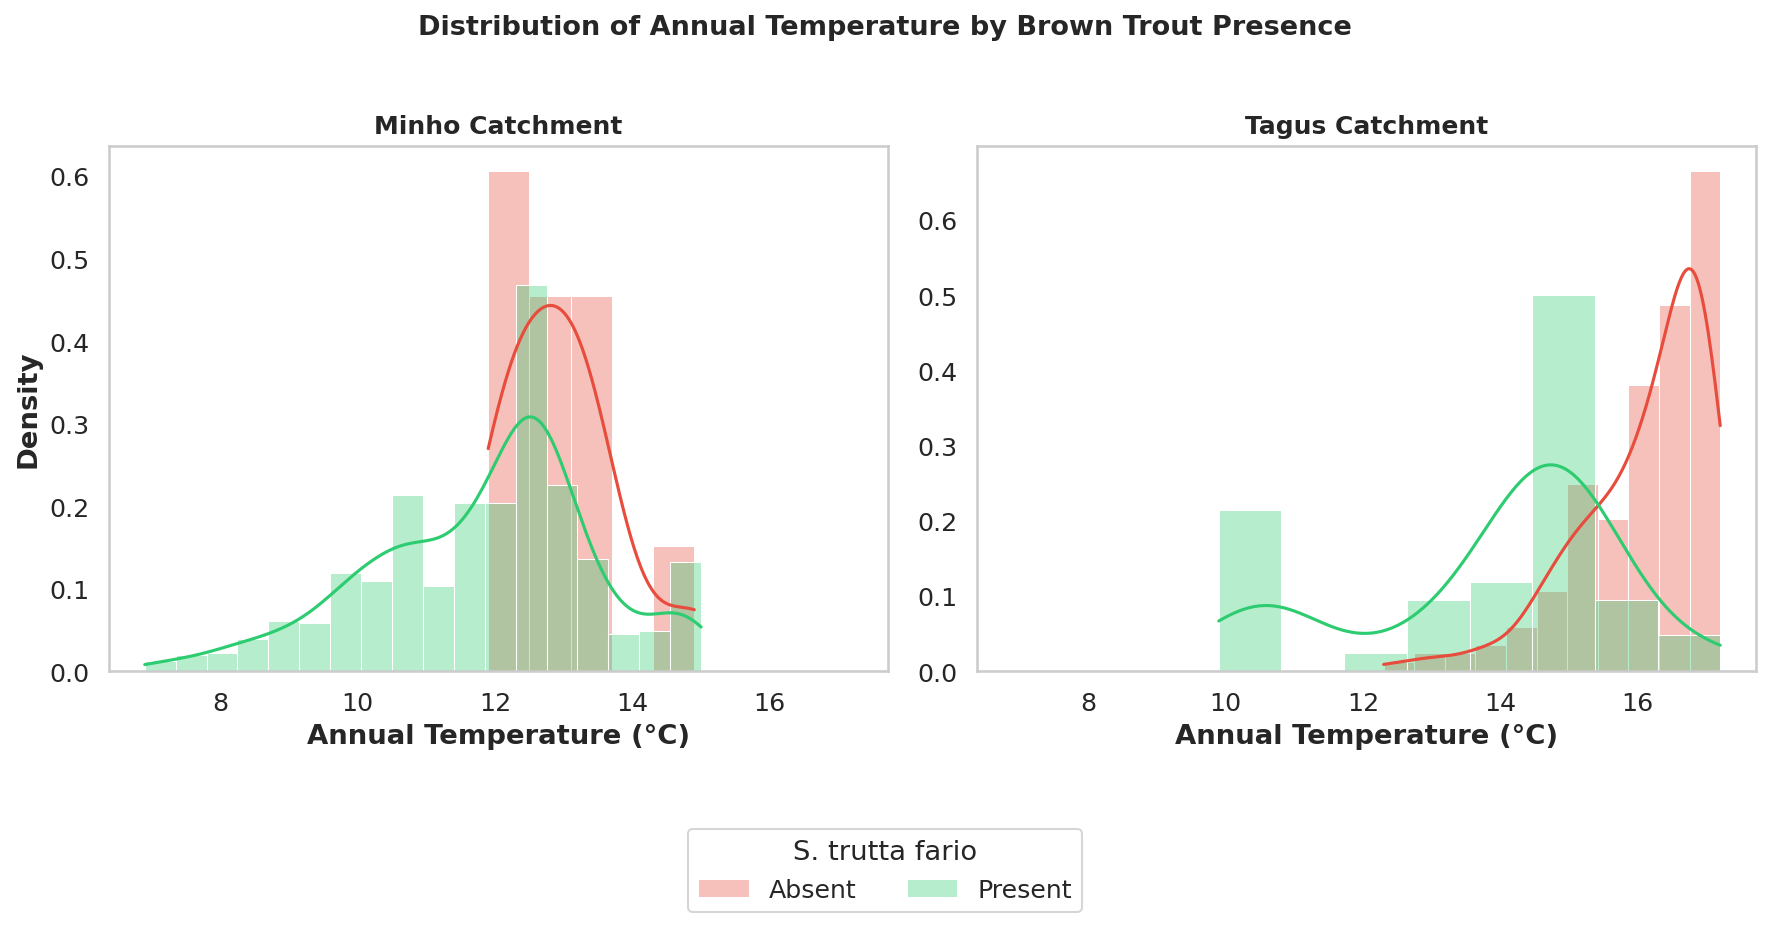

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

for ax, (name, data) in zip(axes, [('Minho', df_minho), ('Tagus', df_tejo)]):
    for group, color in [('Absent', '#e74c3c'), ('Present', '#2ecc71')]:
        subset = data[data['trout_present'] == group]['temp_ann']
        sns.histplot(subset, kde=True, ax=ax, color=color, stat="density",
                     alpha=0.35, edgecolor="white", linewidth=0.5, label=group)
    ax.set_title(f"{name} Catchment", fontsize=12)
    ax.set_xlabel("Annual Temperature (°C)")
    ax.set_ylabel("Density" if ax == axes[0] else "")
    ax.legend().remove()  # Remove individual legends
    ax.grid(False)

fig.suptitle("Distribution of Annual Temperature by Brown Trout Presence", fontsize=13, fontweight='bold', y=1.02)

# Single shared legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="S. trutta fario", loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

In Minho, the temperature difference between trout present and trout absent sites is small. The boxplots largely overlap, with medians around 12.2 °C (present) and 13.0 °C (absent), and the histograms confirm both groups share a similar range (8–15 °C).

In Tegus, the separation is much stronger. Trout present sites cluster around 14–15 °C, while trout-absent sites concentrate around 16–17 °C with minimal overlap.